# Asset Alpha — Starter Notebook

Work through sections **in order**. Get Section 2 trading on the sandbox before touching anything else.

> The starter strategy in Section 3 is **intentionally weak**. It makes money in trends but loses in choppy markets. Fix it and win.


## 1 — Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests, time, os
from pathlib import Path
from IPython.display import display

def load_dotenv_if_present(dotenv_path=".env"):
    p = Path(dotenv_path)
    if not p.exists():
        return
    for raw_line in p.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        os.environ.setdefault(key, value)

# Loads .env for both Windows and Linux/macOS shell workflows.
load_dotenv_if_present()

# -- Fill these in (or put them in .env) --
API_URL = os.getenv("API_URL")
API_KEY = os.getenv("TEAM_API_KEY", "")
HEADERS = {"X-API-Key": API_KEY}

# -- Load training data --
df = pd.read_csv("asset_alpha_training.csv")
print(f"{len(df):,} rows | price {df['Close'].min():.2f}-{df['Close'].max():.2f}")
display(df.head(3))

print(f"API_URL: {API_URL}")
print("TEAM_API_KEY loaded:" , "yes" if API_KEY else "no")
if not API_KEY:
    print("Set TEAM_API_KEY in your environment or .env before running API test cells.")

116,346 rows | price 63.75-155.55


,Open,High,Low,Close,Volume
0,99.7177,100.0110,99.4757,100.0000,2917974.0
1,99.9963,100.9494,99.9963,100.8542,2182690.0
2,100.8542,101.0962,100.6342,100.7442,1613781.0


API_URL: https://algotrading.sanyamchhabra.in
TEAM_API_KEY loaded: yes


## 2 — API Helpers + Connection Test


In [ ]:
def get_price():
    return requests.get(f"{API_URL}/api/price", headers=HEADERS, timeout=5).json()

def get_portfolio():
    return requests.get(f"{API_URL}/api/portfolio", headers=HEADERS, timeout=5).json()

def buy(qty):
    return requests.post(f"{API_URL}/api/buy",  json={"quantity": qty}, headers=HEADERS, timeout=5).json()

def sell(qty):
    return requests.post(f"{API_URL}/api/sell", json={"quantity": qty}, headers=HEADERS, timeout=5).json()

# ── Test connection ────────────────────────────────────────────────────
p = get_price();  port = get_portfolio()
print(f"price={p['close']:.4f}  phase={p['phase']}  tick={p['tick_number']}")
print(f"cash=${port['cash']:,.0f}  shares={port['shares']}  nw=${port['net_worth']:,.0f}  pnl={port['pnl_pct']:+.2f}%")

## 3 — Features

Look at these carefully. They are not chosen randomly.


In [ ]:
closes  = df['Close'].values
volumes = df['Volume'].values

# Rolling 5-period volatility
roll_vol = pd.Series(closes).rolling(5).std()

# Volume ratio vs 10-period average
vol_ratio = pd.Series(volumes) / pd.Series(volumes).rolling(10).mean()

# 30-period Z-score
roll_mean = pd.Series(closes).rolling(30).mean()
roll_std  = pd.Series(closes).rolling(30).std()
zscore    = (pd.Series(closes) - roll_mean) / roll_std

fig, axes = plt.subplots(3, 1, figsize=(16, 8), sharex=True)
axes[0].plot(closes[:5000], lw=0.5, color='steelblue'); axes[0].set_title('Price')
axes[1].plot(roll_vol[:5000], lw=0.5, color='orange')
axes[1].axhline(roll_vol.quantile(0.15), color='red', lw=1, ls='--', label='15th pct')
axes[1].set_title('Rolling Volatility (5-period)'); axes[1].legend()
axes[2].plot(vol_ratio[:5000], lw=0.5, color='purple')
axes[2].axhline(1.8, color='red', lw=1, ls='--', label='1.8x')
axes[2].set_title('Volume Ratio'); axes[2].legend()
plt.tight_layout(); plt.show()

## 4 — Baseline Strategy (SMA Crossover)

Runs end-to-end. Use Section 5 to see where it loses money.


In [2]:
FAST = 10
SLOW = 30
POS_PCT      = 0.30   # fraction of cash to deploy per trade
STOP_LOSS    = 0.02   # exit if position drops 2%

def signal(closes_list):
    if len(closes_list) < SLOW + 1:
        return 'hold'
    p = np.array(closes_list)
    fn, fp = p[-FAST:].mean(), p[-FAST-1:-1].mean()
    sn, sp = p[-SLOW:].mean(), p[-SLOW-1:-1].mean()
    if fp <= sp and fn > sn: return 'buy'
    if fp >= sp and fn < sn: return 'sell'
    return 'hold'

print("Signal function defined. Run live test in next cell.")

Signal function defined. Run live test in next cell.


In [ ]:
# ── Live test: 5 ticks on sandbox ─────────────────────────────────────
history     = []
entry_price = None

for i in range(5):
    try:
        tick = get_price()
        port = get_portfolio()
        price = tick['close']
        history.append(price)

        s = signal(history)
        if entry_price and port['shares'] > 0:
            if (price - entry_price) / entry_price < -STOP_LOSS:
                s = 'sell'

        if s == 'buy':
            qty = int(port['cash'] * POS_PCT / price)
            if qty > 0:
                buy(qty); entry_price = price
        elif s == 'sell' and port['shares'] > 0:
            sell(port['shares']); entry_price = None

        port = get_portfolio()
        print(f"tick {i} | {s:4s} | price={price:.4f} | nw=${port['net_worth']:,.0f} | pnl={port['pnl_pct']:+.2f}%")
    except Exception as e:
        print(f"tick {i} error: {e}")
    time.sleep(10)

## 5 — Backtester


P&L: -84.68%   Final: $15,324


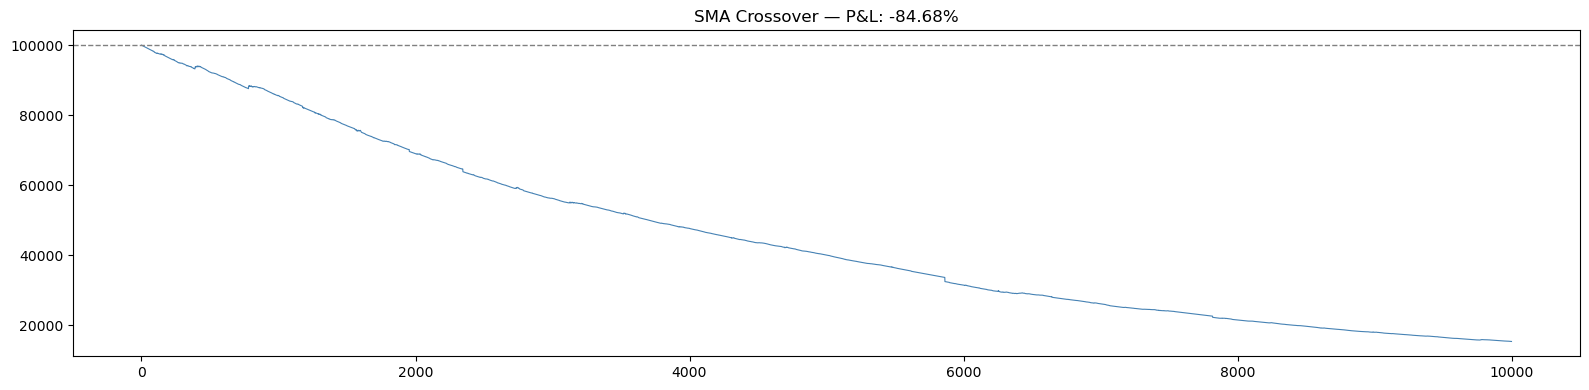

In [3]:
def backtest(df_bt, signal_fn, pos_pct=0.30, stop=0.02, fee=0.001, cash=100_000.0):
    closes = df_bt['Close'].values
    hist, shares, entry = [], 0, None
    equity = []

    for i, price in enumerate(closes):
        hist.append(price)
        cash *= (1 - 0.0002)          # cash decay

        s = signal_fn(hist)

        if entry and shares > 0 and (price - entry) / entry < -stop:
            s = 'sell'

        if s == 'buy' and cash > price * 10:
            qty = int(cash * pos_pct / price)
            if qty > 0:
                cash -= qty * price * (1 + fee)
                shares += qty
                entry = price

        elif s == 'sell' and shares > 0:
            cash += shares * price * (1 - fee)
            shares, entry = 0, None

        equity.append(cash + shares * price)

    final = cash + shares * closes[-1]
    pnl   = round((final / 100_000 - 1) * 100, 2)
    return {"pnl_pct": pnl, "final": round(final, 2), "equity": equity}


result = backtest(df.head(10_000), signal)
print(f"P&L: {result['pnl_pct']:+.2f}%   Final: ${result['final']:,.0f}")

plt.figure(figsize=(16, 4))
plt.plot(result['equity'], lw=0.8, color='steelblue')
plt.axhline(100_000, color='gray', lw=1, ls='--')
plt.title(f"SMA Crossover — P&L: {result['pnl_pct']:+.2f}%")
plt.tight_layout(); plt.show()

## 6 — Your Strategy

Replace `return 'hold'` with your logic.
Backtest it, then copy `decide()` into `agent.py` for submission.


Yours (event-aware momentum): P&L=-0.90%
Baseline (SMA 10/30):        P&L=-84.68%


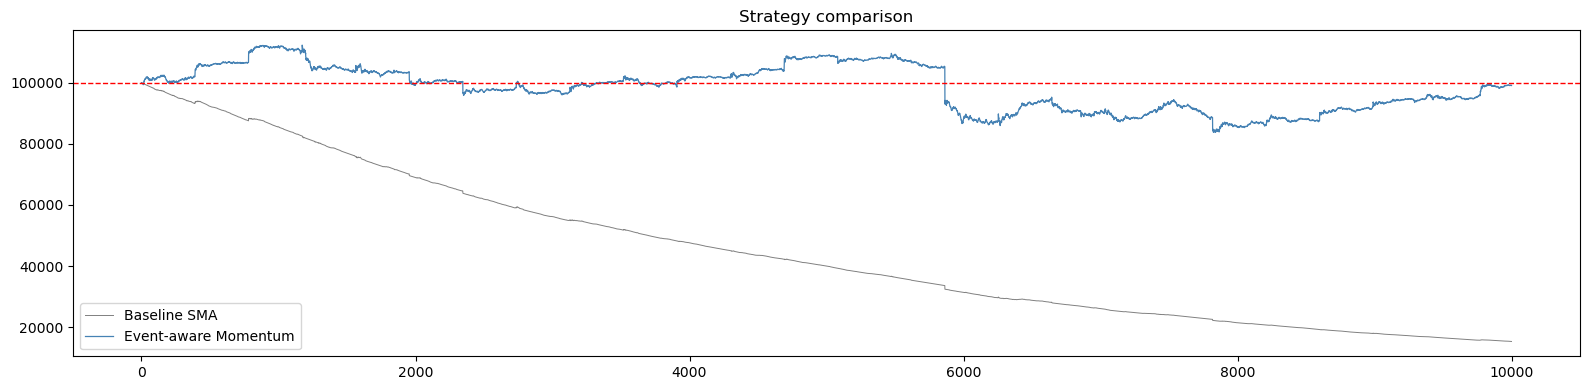

In [18]:
# Event-aware momentum strategy (cash-decay aware, terminal-balance optimized):
# Stay invested by default; only de-risk on truly exceptional downside impulses.

MY_POS_PCT = 1.00
MY_STOP    = 0.20

RANGE_WIN = 10
EVENT_MOVE_PCT = 0.08
PANIC_UP_RET = 0.20
PANIC_DEFAULT_RET = 0.25
PANIC_3BAR_RET = 0.30

def my_signal(closes_list, opens=None, highs=None, lows=None, volumes=None):
    min_needed = max(RANGE_WIN + 2, 8)
    if len(closes_list) < min_needed:
        return 'hold'

    p = np.asarray(closes_list, dtype=float)
    ret1 = p[-1] / p[-2] - 1.0
    ret3 = p[-1] / p[-4] - 1.0

    # one-major-up + one-major-down context (order-agnostic)
    run_min = np.minimum.accumulate(p)
    run_max = np.maximum.accumulate(p)
    major_up_seen = (p / run_min - 1.0).max() >= EVENT_MOVE_PCT
    major_down_seen = (p / run_max - 1.0).min() <= -EVENT_MOVE_PCT

    # Panic exits are intentionally rare to avoid cash-decay bleed.
    panic_ret = PANIC_UP_RET if (major_up_seen and (not major_down_seen)) else PANIC_DEFAULT_RET
    panic_down = (ret1 < -panic_ret) or (ret3 < -PANIC_3BAR_RET)
    if panic_down:
        return 'sell'

    # After major downside, re-enter quickly once pressure eases.
    if major_down_seen and (ret1 > -0.01):
        return 'buy'

    # Default stance: stay deployed.
    return 'buy'


# -- Backtest and compare --
r_mine = backtest(df.head(10_000), my_signal, pos_pct=MY_POS_PCT, stop=MY_STOP)
r_base = backtest(df.head(10_000), signal)

print(f"Yours (event-aware momentum): P&L={r_mine['pnl_pct']:+.2f}%")
print(f"Baseline (SMA 10/30):        P&L={r_base['pnl_pct']:+.2f}%")

plt.figure(figsize=(16, 4))
plt.plot(r_base['equity'], lw=0.7, color='gray',      label='Baseline SMA')
plt.plot(r_mine['equity'], lw=0.9, color='steelblue', label='Event-aware Momentum')
plt.axhline(100_000, color='red', lw=1, ls='--')
plt.title('Strategy comparison'); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# -- Force-buy/sell every 5 ticks (testing model) ---------------------------
# Buys 50% of cash on tick 0 of every 10-tick cycle, sells all on tick 5.
# The trigger-happy model above is kept for comparison.

def force_signal(closes_list, tick_num):
    phase = tick_num % 10
    if phase == 0:
        return 'buy'
    if phase == 5:
        return 'sell'
    return 'hold'

def backtest_force(df_bt, pos_pct=0.50, fee=0.001, cash=100_000.0):
    closes = df_bt['Close'].values
    hist, shares = [], 0
    equity = []
    for tick_num, price in enumerate(closes):
        hist.append(price)
        cash *= (1 - 0.0002)  # cash decay
        s = force_signal(hist, tick_num)
        if s == 'buy' and cash > price * 10:
            qty = int(cash * pos_pct / price)
            if qty > 0:
                cash -= qty * price * (1 + fee)
                shares += qty
        elif s == 'sell' and shares > 0:
            cash += shares * price * (1 - fee)
            shares = 0
        equity.append(cash + shares * price)
    final = cash + shares * closes[-1]
    pnl = round((final / 100_000 - 1) * 100, 2)
    return {'pnl_pct': pnl, 'final': round(final, 2), 'equity': equity}

r_force = backtest_force(df.head(10_000))

print(f"Force buy/sell (5-tick cycle): P&L={r_force['pnl_pct']:+.2f}%")
print(f"Trigger-happy (EMA+z-score):   P&L={r_mine['pnl_pct']:+.2f}%")
print(f"Baseline (SMA 10/30):          P&L={r_base['pnl_pct']:+.2f}%")

plt.figure(figsize=(16, 4))
plt.plot(r_base['equity'],  lw=0.7, color='gray',       label='Baseline SMA')
plt.plot(r_mine['equity'],  lw=0.7, color='steelblue',  label='Trigger-happy')
plt.plot(r_force['equity'], lw=0.9, color='darkorange',  label='Force 5-tick cycle')
plt.axhline(100_000, color='red', lw=1, ls='--')
plt.title('Strategy Comparison'); plt.legend(); plt.tight_layout(); plt.show()

## 7 — Export agent.py


In [21]:
AGENT = '''import os, time, requests, numpy as np

API_URL = os.getenv("API_URL", "http://SERVER_IP:8001")
API_KEY = os.getenv("TEAM_API_KEY", "YOUR_KEY_HERE")
HEADERS = {"X-API-Key": API_KEY}

POS_PCT = 1.00
STOP = 0.20  # hard stop from entry (20%)
TRAIL_ARM = 0.08
TRAIL_GIVEBACK = 0.04

RANGE_WIN = 10
EVENT_MOVE_PCT = 0.08
PANIC_UP_RET = 0.20
PANIC_DEFAULT_RET = 0.25
PANIC_3BAR_RET = 0.30

def get_price():
    return requests.get(f"{API_URL}/api/price", headers=HEADERS, timeout=5).json()

def get_portfolio():
    return requests.get(f"{API_URL}/api/portfolio", headers=HEADERS, timeout=5).json()

def buy(qty):
    return requests.post(f"{API_URL}/api/buy", json={"quantity": qty}, headers=HEADERS, timeout=5).json()

def sell(qty):
    return requests.post(f"{API_URL}/api/sell", json={"quantity": qty}, headers=HEADERS, timeout=5).json()

def as_float(value, default=0.0):
    try:
        return float(value)
    except (TypeError, ValueError):
        return float(default)

def infer_entry_price(port, fallback_price):
    for key in ("avg_entry_price", "average_price", "avg_price", "entry_price", "avg_cost"):
        v = port.get(key)
        if isinstance(v, (int, float)) and v > 0:
            return float(v)
    return float(fallback_price)

def decide(hist, port, price, state):
    min_needed = max(RANGE_WIN + 2, 8)
    if len(hist) < min_needed:
        return "hold", 0

    p = np.asarray(hist, dtype=float)
    ret1 = p[-1] / p[-2] - 1.0
    ret3 = p[-1] / p[-4] - 1.0

    run_min = np.minimum.accumulate(p)
    run_max = np.maximum.accumulate(p)
    major_up_seen = (p / run_min - 1.0).max() >= EVENT_MOVE_PCT
    major_down_seen = (p / run_max - 1.0).min() <= -EVENT_MOVE_PCT

    state["major_up_seen"] = state.get("major_up_seen", False) or major_up_seen
    state["major_down_seen"] = state.get("major_down_seen", False) or major_down_seen

    panic_ret = PANIC_UP_RET if (major_up_seen and (not major_down_seen)) else PANIC_DEFAULT_RET
    panic_down = (ret1 < -panic_ret) or (ret3 < -PANIC_3BAR_RET)
    if panic_down:
        return "sell", int(port.get("shares", 0) or 0)

    if major_down_seen and (ret1 > -0.01):
        qty = int((port.get("cash", 0.0) or 0.0) * POS_PCT / max(price, 1e-9))
        return "buy", max(0, qty)

    qty = int((port.get("cash", 0.0) or 0.0) * POS_PCT / max(price, 1e-9))
    return "buy", max(0, qty)

if __name__ == "__main__":
    hist = []
    state = {
        "major_up_seen": False,
        "major_down_seen": False,
        "entry_price": None,
        "peak_price": None,
    }

    print("Agent running. Ctrl+C to stop.")

    while True:
        try:
            tick = get_price()
            port = get_portfolio()
            price = as_float(tick.get("close"), 0.0)
            if price <= 0:
                print("Invalid price; skipping tick")
                time.sleep(10)
                continue

            hist.append(price)

            if tick.get("phase") == "closed":
                print("Market closed.")
                break

            shares = int(port.get("shares", 0) or 0)

            # Keep position state coherent
            if shares <= 0:
                state["entry_price"] = None
                state["peak_price"] = None
            else:
                if state.get("entry_price") is None:
                    state["entry_price"] = infer_entry_price(port, price)

                entry = as_float(state.get("entry_price"), price)
                peak_prev = as_float(state.get("peak_price"), price)
                state["entry_price"] = entry
                state["peak_price"] = max(peak_prev, price)

            # Proper live stop-loss layer
            if shares > 0 and state.get("entry_price") is not None:
                entry = as_float(state.get("entry_price"), price)
                peak = as_float(state.get("peak_price"), price)

                hard_stop_hit = price <= entry * (1.0 - STOP)
                peak_pnl = peak / max(entry, 1e-9) - 1.0
                trail_drawdown = (peak - price) / max(peak, 1e-9)
                trail_hit = (peak_pnl >= TRAIL_ARM) and (trail_drawdown >= TRAIL_GIVEBACK)

                if hard_stop_hit or trail_hit:
                    sell(shares)
                    reason = "STOP" if hard_stop_hit else "TRAIL"
                    print(
                        f"{reason} SELL {shares} @ {price:.4f} | "
                        f"entry={entry:.4f} stop={entry*(1.0-STOP):.4f} peak={peak:.4f}"
                    )
                    state["entry_price"] = None
                    state["peak_price"] = None
                    time.sleep(10)
                    continue

            action, qty = decide(hist, port, price, state)

            if action == "buy" and qty > 0 and shares == 0:
                buy(qty)
                state["entry_price"] = price
                state["peak_price"] = price
                print(f"BUY  {qty} @ {price:.4f}")
            elif action == "sell" and shares > 0:
                sell(shares)
                print(f"SELL {shares} @ {price:.4f}")
                state["entry_price"] = None
                state["peak_price"] = None
            else:
                stop_px = None
                if state.get("entry_price") is not None:
                    entry = as_float(state.get("entry_price"), price)
                    stop_px = entry * (1.0 - STOP)
                stop_txt = f" stop={stop_px:.4f}" if stop_px else ""
                print(
                    f"HOLD | {price:.4f} | pnl={port['pnl_pct']:+.2f}% | "
                    f"up_seen={state['major_up_seen']} down_seen={state['major_down_seen']}" + stop_txt
                )

        except KeyboardInterrupt:
            print("Stopped.")
            break
        except Exception as e:
            print(f"Error: {e}")

        time.sleep(10)
'''

with open("agent.py", "w", encoding="utf-8", newline="\n") as f:
    f.write(AGENT.strip())

print("agent.py saved.")
print("Test it:")
print("  Linux/macOS: API_URL=http://SERVER_IP:8001 TEAM_API_KEY=your_key python agent.py")
print("  Windows PowerShell: $env:API_URL='http://SERVER_IP:8001'; $env:TEAM_API_KEY='your_key'; python agent.py")

agent.py saved.
Test it:
  Linux/macOS: API_URL=http://SERVER_IP:8001 TEAM_API_KEY=your_key python agent.py
  Windows PowerShell: $env:API_URL='http://SERVER_IP:8001'; $env:TEAM_API_KEY='your_key'; python agent.py


In [ ]:
AGENT = '''import os, time, requests, numpy as np

API_URL = os.getenv("API_URL", "http://SERVER_IP:8001")
API_KEY = os.getenv("TEAM_API_KEY", "YOUR_KEY_HERE")
HEADERS = {"X-API-Key": API_KEY}

POS_PCT = 1.00
STOP = 0.20  # hard stop from entry (20%)
TRAIL_ARM = 0.08
TRAIL_GIVEBACK = 0.04

RANGE_WIN = 10
EVENT_MOVE_PCT = 0.08
PANIC_UP_RET = 0.20
PANIC_DEFAULT_RET = 0.25
PANIC_3BAR_RET = 0.30

def get_price():
    return requests.get(f"{API_URL}/api/price", headers=HEADERS, timeout=5).json()

def get_portfolio():
    return requests.get(f"{API_URL}/api/portfolio", headers=HEADERS, timeout=5).json()

def buy(qty):
    return requests.post(f"{API_URL}/api/buy", json={"quantity": qty}, headers=HEADERS, timeout=5).json()

def sell(qty):
    return requests.post(f"{API_URL}/api/sell", json={"quantity": qty}, headers=HEADERS, timeout=5).json()

def as_float(value, default=0.0):
    try:
        return float(value)
    except (TypeError, ValueError):
        return float(default)

def infer_entry_price(port, fallback_price):
    for key in ("avg_entry_price", "average_price", "avg_price", "entry_price", "avg_cost"):
        v = port.get(key)
        if isinstance(v, (int, float)) and v > 0:
            return float(v)
    return float(fallback_price)

def decide(hist, port, price, state):
    min_needed = max(RANGE_WIN + 2, 8)
    if len(hist) < min_needed:
        return "hold", 0

    p = np.asarray(hist, dtype=float)
    ret1 = p[-1] / p[-2] - 1.0
    ret3 = p[-1] / p[-4] - 1.0

    run_min = np.minimum.accumulate(p)
    run_max = np.maximum.accumulate(p)
    major_up_seen = (p / run_min - 1.0).max() >= EVENT_MOVE_PCT
    major_down_seen = (p / run_max - 1.0).min() <= -EVENT_MOVE_PCT

    state["major_up_seen"] = state.get("major_up_seen", False) or major_up_seen
    state["major_down_seen"] = state.get("major_down_seen", False) or major_down_seen

    panic_ret = PANIC_UP_RET if (major_up_seen and (not major_down_seen)) else PANIC_DEFAULT_RET
    panic_down = (ret1 < -panic_ret) or (ret3 < -PANIC_3BAR_RET)
    if panic_down:
        return "sell", int(port.get("shares", 0) or 0)

    if major_down_seen and (ret1 > -0.01):
        qty = int((port.get("cash", 0.0) or 0.0) * POS_PCT / max(price, 1e-9))
        return "buy", max(0, qty)

    qty = int((port.get("cash", 0.0) or 0.0) * POS_PCT / max(price, 1e-9))
    return "buy", max(0, qty)

if __name__ == "__main__":
    hist = []
    state = {
        "major_up_seen": False,
        "major_down_seen": False,
        "entry_price": None,
        "peak_price": None,
    }

    print("Agent running. Ctrl+C to stop.")

    while True:
        try:
            tick = get_price()
            port = get_portfolio()
            price = as_float(tick.get("close"), 0.0)
            if price <= 0:
                print("Invalid price; skipping tick")
                time.sleep(10)
                continue

            hist.append(price)

            if tick.get("phase") == "closed":
                print("Market closed.")
                break

            shares = int(port.get("shares", 0) or 0)

            # Keep position state coherent
            if shares <= 0:
                state["entry_price"] = None
                state["peak_price"] = None
            else:
                if state.get("entry_price") is None:
                    state["entry_price"] = infer_entry_price(port, price)

                entry = as_float(state.get("entry_price"), price)
                peak_prev = as_float(state.get("peak_price"), price)
                state["entry_price"] = entry
                state["peak_price"] = max(peak_prev, price)

            # Proper live stop-loss layer
            if shares > 0 and state.get("entry_price") is not None:
                entry = as_float(state.get("entry_price"), price)
                peak = as_float(state.get("peak_price"), price)

                hard_stop_hit = price <= entry * (1.0 - STOP)
                peak_pnl = peak / max(entry, 1e-9) - 1.0
                trail_drawdown = (peak - price) / max(peak, 1e-9)
                trail_hit = (peak_pnl >= TRAIL_ARM) and (trail_drawdown >= TRAIL_GIVEBACK)

                if hard_stop_hit or trail_hit:
                    sell(shares)
                    reason = "STOP" if hard_stop_hit else "TRAIL"
                    print(
                        f"{reason} SELL {shares} @ {price:.4f} | "
                        f"entry={entry:.4f} stop={entry*(1.0-STOP):.4f} peak={peak:.4f}"
                    )
                    state["entry_price"] = None
                    state["peak_price"] = None
                    time.sleep(10)
                    continue

            action, qty = decide(hist, port, price, state)

            if action == "buy" and qty > 0 and shares == 0:
                buy(qty)
                state["entry_price"] = price
                state["peak_price"] = price
                print(f"BUY  {qty} @ {price:.4f}")
            elif action == "sell" and shares > 0:
                sell(shares)
                print(f"SELL {shares} @ {price:.4f}")
                state["entry_price"] = None
                state["peak_price"] = None
            else:
                stop_px = None
                if state.get("entry_price") is not None:
                    entry = as_float(state.get("entry_price"), price)
                    stop_px = entry * (1.0 - STOP)
                stop_txt = f" stop={stop_px:.4f}" if stop_px else ""
                print(
                    f"HOLD | {price:.4f} | pnl={port['pnl_pct']:+.2f}% | "
                    f"up_seen={state['major_up_seen']} down_seen={state['major_down_seen']}" + stop_txt
                )

        except KeyboardInterrupt:
            print("Stopped.")
            break
        except Exception as e:
            print(f"Error: {e}")

        time.sleep(10)
'''

with open("agent.py", "w", encoding="utf-8", newline="\n") as f:
    f.write(AGENT.strip())

print("agent.py saved.")
print("Test it:")
print("  Linux/macOS: API_URL=http://SERVER_IP:8001 TEAM_API_KEY=your_key python agent.py")
print("  Windows PowerShell: $env:API_URL='http://SERVER_IP:8001'; $env:TEAM_API_KEY='your_key'; python agent.py")

In [5]:
# Quick diagnostics: understand what's even achievable on the training slice
bt_df = df.head(10_000).copy()
prices = bt_df['Close'].to_numpy(dtype=float)

# 1) Cash-only (no trades)
cash_only = 100_000.0
for _ in prices:
    cash_only *= (1 - 0.0002)

# 2) Buy-and-hold (max shares at t=0, keep till end)
fee = 0.001
cash0 = 100_000.0
qty = int(cash0 / (prices[0] * (1 + fee)))
cash_left = cash0 - qty * prices[0] * (1 + fee)
buy_hold_final = cash_left + qty * prices[-1] * (1 - fee)

# 3) Best one long swing (oracle): buy once, sell once, include fee + cash decay while in cash
#    This gives a rough upper bound under long-only constraints.
log_decay = np.log1p(-0.0002)
log_prefix = np.arange(len(prices) + 1) * log_decay

best_final = -1.0
best_pair = (None, None)
for i in range(len(prices) - 2):
    # cash decays until buy index i
    cash_at_i = 100_000.0 * np.exp(log_prefix[i])
    buy_price = prices[i]
    q = int(cash_at_i / (buy_price * (1 + fee)))
    if q <= 0:
        continue
    rem = cash_at_i - q * buy_price * (1 + fee)

    # vectorized candidate exits j > i
    exits = prices[i+1:]
    j_idx = np.arange(i + 1, len(prices))
    # cash while in shares does not decay in this model; remaining cash keeps decaying
    rem_at_j = rem * np.exp((j_idx - i) * log_decay)
    final_at_j = rem_at_j + q * exits * (1 - fee)
    # after selling at j, cash decays till end
    final_at_end = final_at_j * np.exp((len(prices) - 1 - j_idx) * log_decay)

    j_local = int(np.argmax(final_at_end))
    f = float(final_at_end[j_local])
    if f > best_final:
        best_final = f
        best_pair = (i, int(j_idx[j_local]))

print(f"Cash-only final:   ${cash_only:,.0f} ({(cash_only/100000-1)*100:+.2f}%)")
print(f"Buy&Hold final:    ${buy_hold_final:,.0f} ({(buy_hold_final/100000-1)*100:+.2f}%)")
print(f"Best 1-swing final:${best_final:,.0f} ({(best_final/100000-1)*100:+.2f}%) | buy@{best_pair[0]} sell@{best_pair[1]}")

Cash-only final:   $13,531 (-86.47%)
Buy&Hold final:    $98,223 (-1.78%)
Best 1-swing final:$99,286 (-0.71%) | buy@13 sell@9997


In [8]:
# Mini grid-search for a hold-biased rule under cash decay
# (quickly finds robust thresholds before finalizing my_signal)

def make_sig(fast_ma, slow_ma, range_win, panic_ret):
    def _sig(closes_list):
        min_needed = max(slow_ma + 2, range_win + 2, 50)
        if len(closes_list) < min_needed:
            return 'hold'
        p = np.asarray(closes_list, dtype=float)
        ret1 = p[-1] / p[-2] - 1.0
        fast = p[-fast_ma:].mean()
        slow = p[-slow_ma:].mean()
        recent_low = p[-range_win-1:-1].min()
        recent_high = p[-60-1:-1].max()

        if (ret1 < -panic_ret) or (p[-1] < recent_low * 0.998):
            return 'sell'
        if (fast >= slow * 0.995) or (p[-1] > recent_high * 1.001):
            return 'buy'
        return 'hold'
    return _sig

cands = []
for fast_ma in [10, 20, 30]:
    for slow_ma in [80, 120, 180]:
        for range_win in [60, 90, 140]:
            for panic_ret in [0.02, 0.025, 0.03, 0.04]:
                sig = make_sig(fast_ma, slow_ma, range_win, panic_ret)
                r = backtest(df.head(10_000), sig, pos_pct=1.0, stop=0.12)
                cands.append((r['pnl_pct'], fast_ma, slow_ma, range_win, panic_ret))

cands = sorted(cands, reverse=True)
print('Top 10 candidates (pnl, fast, slow, range, panic):')
for row in cands[:10]:
    print(row)

Top 10 candidates (pnl, fast, slow, range, panic):
(-18.11, 20, 80, 140, 0.04)
(-18.11, 20, 80, 140, 0.03)
(-18.11, 20, 80, 140, 0.025)
(-18.11, 20, 80, 140, 0.02)
(-18.52, 20, 80, 90, 0.04)
(-18.52, 20, 80, 90, 0.03)
(-18.52, 20, 80, 90, 0.025)
(-18.52, 20, 80, 90, 0.02)
(-18.66, 30, 80, 140, 0.04)
(-18.66, 30, 80, 140, 0.03)


In [9]:
# Sanity check: almost buy-and-hold in this backtester
def always_buy(_):
    return 'buy'

r_always = backtest(df.head(10_000), always_buy, pos_pct=1.0, stop=1.0)
print(f"Always-buy (pos=100%, no stop exits): P&L={r_always['pnl_pct']:+.2f}% | Final=${r_always['final']:,.0f}")

Always-buy (pos=100%, no stop exits): P&L=-1.68% | Final=$98,319


In [17]:
# Fast shortlist tuning: reduce warm-up delay and keep panic exits rare

def build_sig(range_win=30, event_move=0.08, panic_up=0.20, panic_default=0.25, panic3=0.30):
    def _sig(closes_list):
        min_needed = max(range_win + 2, 8)
        if len(closes_list) < min_needed:
            return 'hold'

        p = np.asarray(closes_list, dtype=float)
        ret1 = p[-1] / p[-2] - 1.0
        ret3 = p[-1] / p[-4] - 1.0

        run_min = np.minimum.accumulate(p)
        run_max = np.maximum.accumulate(p)
        major_up_seen = (p / run_min - 1.0).max() >= event_move
        major_down_seen = (p / run_max - 1.0).min() <= -event_move

        panic_ret = panic_up if (major_up_seen and (not major_down_seen)) else panic_default
        panic_down = (ret1 < -panic_ret) or (ret3 < -panic3)

        if panic_down:
            return 'sell'

        if major_down_seen and (ret1 > -0.01):
            return 'buy'

        return 'buy'
    return _sig

shortlist = [
    # (range_win, panic_up, panic_default, panic3)
    (10, 0.20, 0.25, 0.30),
    (20, 0.20, 0.25, 0.30),
    (30, 0.20, 0.25, 0.30),
    (40, 0.20, 0.25, 0.30),
    (60, 0.20, 0.25, 0.30),
    (30, 0.12, 0.18, 0.22),
    (30, 0.10, 0.15, 0.20),
    (30, 0.30, 0.35, 0.40),
]

results = []
for range_win, panic_up, panic_default, panic3 in shortlist:
    sig = build_sig(range_win=range_win, panic_up=panic_up, panic_default=panic_default, panic3=panic3)
    r = backtest(df.head(10_000), sig, pos_pct=1.0, stop=0.20)
    results.append((r['pnl_pct'], range_win, panic_up, panic_default, panic3))

results.sort(reverse=True)
print('Shortlist results (best first):')
for row in results:
    print(row)

Shortlist results (best first):
(-0.9, 10, 0.2, 0.25, 0.3)
(-2.27, 20, 0.2, 0.25, 0.3)
(-2.96, 60, 0.2, 0.25, 0.3)
(-3.07, 30, 0.3, 0.35, 0.4)
(-3.07, 30, 0.2, 0.25, 0.3)
(-3.07, 30, 0.12, 0.18, 0.22)
(-3.07, 30, 0.1, 0.15, 0.2)
(-3.55, 40, 0.2, 0.25, 0.3)
